# Previsão de Vendas com Machine Learning

Este projeto tem como objetivo aplicar técnicas de Machine Learning para prever vendas utilizando modelos de regressão.

## Objetivos do projeto

- Entender o problema de negócio
- Carregar e explorar os dados
- Realizar análise exploratória
- Tratar dados faltantes e variáveis categóricas
- Separar dados de treino e teste
- Treinar modelos de regressão
- Avaliar os modelos com MAE, RMSE e R²
- Interpretar os resultados
- Comparar modelos
- Preparar o projeto para publicação no GitHub

## Tipo de problema

Este é um problema de **regressão**, pois o objetivo é prever um valor numérico: vendas, receita ou demanda.

In [3]:
# Importação das bibliotecas iniciais
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Caminho local do projeto
PROJECT_PATH = r"C:\Users\andre\sales-forecasting-ml"

# Caminhos das principais pastas
DATA_PATH = os.path.join(PROJECT_PATH, "data")
MODELS_PATH = os.path.join(PROJECT_PATH, "models")
NOTEBOOKS_PATH = os.path.join(PROJECT_PATH, "notebooks")

# Exibir os caminhos configurados
print("Caminho do projeto:", PROJECT_PATH)
print("Pasta de dados:", DATA_PATH)
print("Pasta de modelos:", MODELS_PATH)
print("Pasta de notebooks:", NOTEBOOKS_PATH)

Caminho do projeto: C:\Users\andre\sales-forecasting-ml
Pasta de dados: C:\Users\andre\sales-forecasting-ml\data
Pasta de modelos: C:\Users\andre\sales-forecasting-ml\models
Pasta de notebooks: C:\Users\andre\sales-forecasting-ml\notebooks


## Fonte dos dados

Neste projeto será utilizado um conjunto de dados de vendas com variáveis relacionadas a produtos, lojas, datas e valores de venda.

O objetivo é construir um modelo de regressão capaz de prever o valor de vendas com base nas características disponíveis.

Nesta primeira versão do projeto, o foco será o aprendizado prático do fluxo completo de Machine Learning:

- entendimento dos dados
- análise exploratória
- preparação dos dados
- treinamento de modelos
- avaliação dos resultados
- interpretação dos resultados para o negócio

In [4]:
# Criando um dataset fictício de vendas para iniciar o projeto

np.random.seed(42)

num_linhas = 500

dados = {
    "data": pd.date_range(start="2023-01-01", periods=num_linhas, freq="D"),
    "loja": np.random.choice(["Loja A", "Loja B", "Loja C"], size=num_linhas),
    "categoria": np.random.choice(["Eletrônicos", "Roupas", "Alimentos", "Casa"], size=num_linhas),
    "preco_unitario": np.random.uniform(10, 500, size=num_linhas).round(2),
    "quantidade_vendida": np.random.randint(1, 50, size=num_linhas),
    "desconto": np.random.uniform(0, 0.30, size=num_linhas).round(2)
}

df = pd.DataFrame(dados)

# Criando a variável alvo: vendas
df["vendas"] = (df["preco_unitario"] * df["quantidade_vendida"] * (1 - df["desconto"])).round(2)

# Visualizar as primeiras linhas
df.head()

,data,loja,categoria,preco_unitario,quantidade_vendida,desconto,vendas
0,2023-01-01,Loja C,Roupas,119.69,6,0.21,567.33
1,2023-01-02,Loja A,Roupas,412.68,5,0.12,1815.79
2,2023-01-03,Loja C,Alimentos,179.09,5,0.14,770.09
3,2023-01-04,Loja C,Roupas,180.33,47,0.21,6695.65
4,2023-01-05,Loja A,Casa,25.58,23,0.01,582.46


In [5]:
# Salvando o dataset na pasta data

arquivo_vendas = os.path.join(DATA_PATH, "sales_data.csv")

df.to_csv(arquivo_vendas, index=False, encoding="utf-8-sig")

print("Dataset salvo com sucesso em:")
print(arquivo_vendas)

Dataset salvo com sucesso em:
C:\Users\andre\sales-forecasting-ml\data\sales_data.csv


## Carregamento dos dados

Após criar o conjunto de dados inicial, o arquivo foi salvo em formato CSV dentro da pasta `data`.

A partir deste ponto, o projeto passa a trabalhar com o carregamento do arquivo salvo, simulando um fluxo mais próximo de um projeto real de Ciência de Dados.

In [6]:
# Carregando o dataset salvo

df = pd.read_csv(arquivo_vendas)

# Visualizar as primeiras linhas
df.head()

,data,loja,categoria,preco_unitario,quantidade_vendida,desconto,vendas
0,2023-01-01,Loja C,Roupas,119.69,6,0.21,567.33
1,2023-01-02,Loja A,Roupas,412.68,5,0.12,1815.79
2,2023-01-03,Loja C,Alimentos,179.09,5,0.14,770.09
3,2023-01-04,Loja C,Roupas,180.33,47,0.21,6695.65
4,2023-01-05,Loja A,Casa,25.58,23,0.01,582.46


## Análise inicial dos dados

Nesta etapa, será realizada uma primeira inspeção do conjunto de dados para entender:

- quantidade de linhas e colunas
- tipos de dados
- existência de valores ausentes
- estatísticas descritivas das variáveis numéricas
- estrutura geral da base

In [7]:
# Verificar quantidade de linhas e colunas

df.shape

(500, 7)

In [8]:
# Verificar valores ausentes

df.isnull().sum()

data                  0
loja                  0
categoria             0
preco_unitario        0
quantidade_vendida    0
desconto              0
vendas                0
dtype: int64

In [9]:
# Estatísticas descritivas das variáveis numéricas

df.describe()

,preco_unitario,quantidade_vendida,desconto,vendas
count,500.000000,500.000000,500.000000,500.000000
mean,260.117360,24.824000,0.148200,5449.858020
std,139.309576,13.932741,0.084652,4450.858222
min,10.120000,1.000000,0.000000,16.090000
25%,145.252500,13.000000,0.070000,1655.960000
50%,269.040000,25.000000,0.150000,4496.820000
75%,375.975000,37.000000,0.220000,8189.967500
max,499.680000,49.000000,0.300000,20356.960000


### Interpretação inicial

O conjunto de dados possui 500 registros e não apresenta valores ausentes.

As principais variáveis numéricas são:

- `preco_unitario`
- `quantidade_vendida`
- `desconto`
- `vendas`

A variável alvo do projeto será `vendas`, pois representa o valor numérico que queremos prever.

Como não existem valores ausentes nesta base inicial, não será necessário aplicar tratamento de dados faltantes nesta etapa.

In [10]:
# Converter a coluna data para o formato datetime

df["data"] = pd.to_datetime(df["data"])

# Verificar novamente os tipos de dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   data                500 non-null    datetime64[ns]
 1   loja                500 non-null    object        
 2   categoria           500 non-null    object        
 3   preco_unitario      500 non-null    float64       
 4   quantidade_vendida  500 non-null    int64         
 5   desconto            500 non-null    float64       
 6   vendas              500 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(2)
memory usage: 27.5+ KB


## Criação de variáveis temporais

A coluna `data` será utilizada para criar novas variáveis que podem ajudar o modelo a identificar padrões relacionados ao tempo.

Serão criadas as seguintes variáveis:

- `ano`
- `mes`
- `dia`
- `dia_da_semana`

Essas variáveis podem ajudar o modelo a capturar diferenças de vendas ao longo do tempo.

In [11]:
# Criar variáveis a partir da coluna data

df["ano"] = df["data"].dt.year
df["mes"] = df["data"].dt.month
df["dia"] = df["data"].dt.day
df["dia_da_semana"] = df["data"].dt.dayofweek

# Visualizar as primeiras linhas com as novas colunas
df.head()

,data,loja,categoria,preco_unitario,quantidade_vendida,desconto,vendas,ano,mes,dia,dia_da_semana
0,2023-01-01,Loja C,Roupas,119.69,6,0.21,567.33,2023,1,1,6
1,2023-01-02,Loja A,Roupas,412.68,5,0.12,1815.79,2023,1,2,0
2,2023-01-03,Loja C,Alimentos,179.09,5,0.14,770.09,2023,1,3,1
3,2023-01-04,Loja C,Roupas,180.33,47,0.21,6695.65,2023,1,4,2
4,2023-01-05,Loja A,Casa,25.58,23,0.01,582.46,2023,1,5,3


## Análise exploratória dos dados

Nesta etapa, serão criados gráficos simples para entender melhor o comportamento das vendas e das principais variáveis do conjunto de dados.

A primeira análise será a distribuição da variável alvo `vendas`.

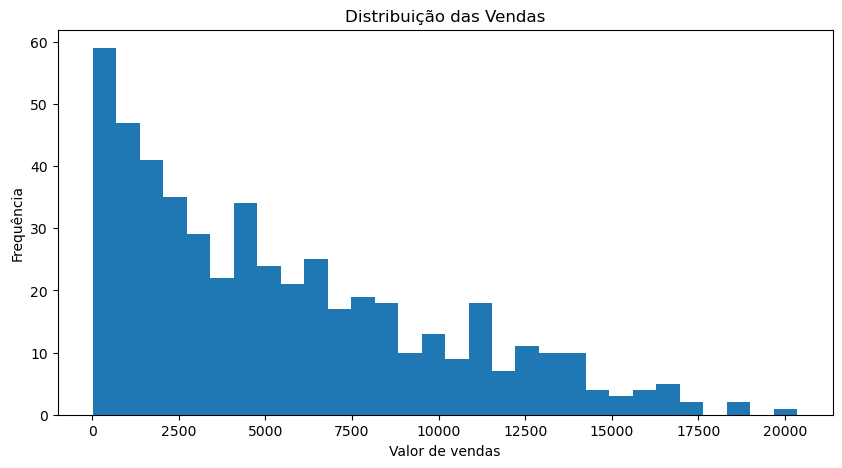

In [12]:
# Distribuição da variável alvo vendas

plt.figure(figsize=(10, 5))
plt.hist(df["vendas"], bins=30)
plt.title("Distribuição das Vendas")
plt.xlabel("Valor de vendas")
plt.ylabel("Frequência")
plt.show()

### Interpretação da distribuição de vendas

A maior parte das vendas está concentrada em valores mais baixos e médios.

Também existem alguns registros com valores mais altos, acima de 15.000, porém com menor frequência.

A distribuição apresenta assimetria à direita, o que indica que poucas vendas possuem valores muito elevados em relação à maioria dos registros.

In [13]:
# Média de vendas por categoria

vendas_por_categoria = df.groupby("categoria")["vendas"].mean().sort_values(ascending=False)

vendas_por_categoria

categoria
Roupas         5582.174435
Alimentos      5523.224530
Casa           5378.076750
Eletrônicos    5347.246419
Name: vendas, dtype: float64

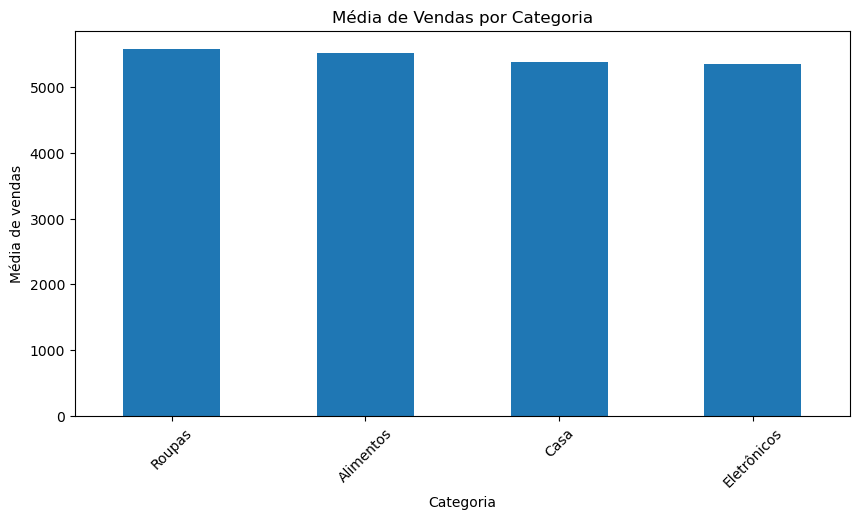

In [14]:
# Gráfico da média de vendas por categoria

plt.figure(figsize=(10, 5))
vendas_por_categoria.plot(kind="bar")
plt.title("Média de Vendas por Categoria")
plt.xlabel("Categoria")
plt.ylabel("Média de vendas")
plt.xticks(rotation=45)
plt.show()

### Interpretação das vendas por categoria

A média de vendas por categoria apresenta valores relativamente próximos entre os grupos.

As categorias `Roupas` e `Alimentos` aparecem com médias um pouco maiores, enquanto `Casa` e `Eletrônicos` apresentam médias ligeiramente menores.

Como este dataset inicial foi criado para fins didáticos, as diferenças entre categorias não são muito grandes, mas a análise mostra como comparar o comportamento das vendas entre grupos de produtos.

In [15]:
# Média de vendas por loja

vendas_por_loja = df.groupby("loja")["vendas"].mean().sort_values(ascending=False)

vendas_por_loja

loja
Loja C    5860.497273
Loja A    5564.394226
Loja B    4928.914551
Name: vendas, dtype: float64

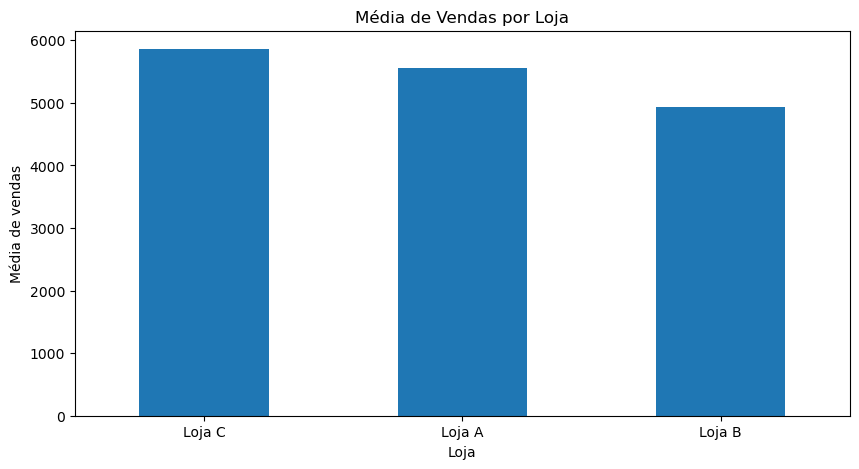

In [16]:
# Gráfico da média de vendas por loja

plt.figure(figsize=(10, 5))
vendas_por_loja.plot(kind="bar")
plt.title("Média de Vendas por Loja")
plt.xlabel("Loja")
plt.ylabel("Média de vendas")
plt.xticks(rotation=0)
plt.show()

### Interpretação das vendas por loja

A média de vendas varia entre as lojas.

A `Loja C` apresenta a maior média de vendas, seguida pela `Loja A`.

A `Loja B` apresenta a menor média de vendas entre as três lojas analisadas.

Essa análise pode indicar diferenças de desempenho entre unidades, comportamento de clientes, mix de produtos ou volume médio de compras.

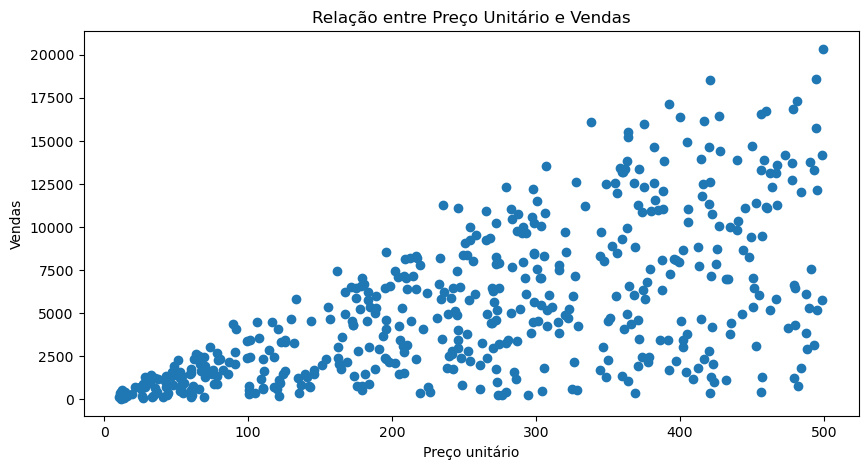

In [17]:
# Relação entre preço unitário e vendas

plt.figure(figsize=(10, 5))
plt.scatter(df["preco_unitario"], df["vendas"])
plt.title("Relação entre Preço Unitário e Vendas")
plt.xlabel("Preço unitário")
plt.ylabel("Vendas")
plt.show()

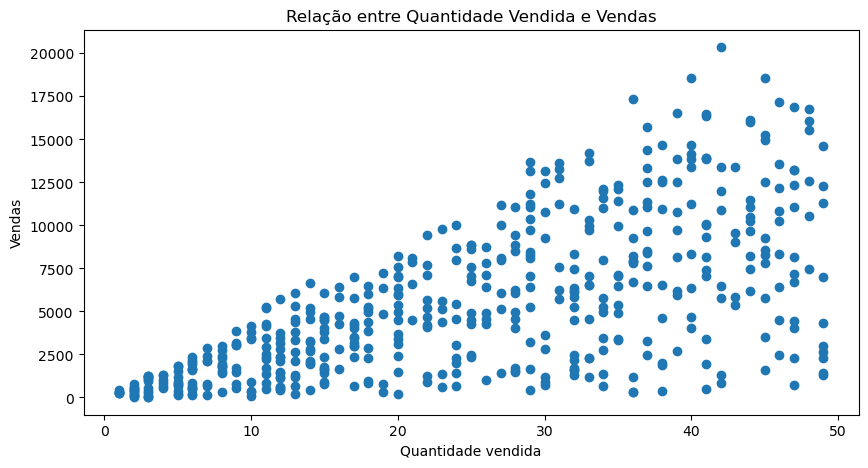

In [18]:
# Relação entre quantidade vendida e vendas

plt.figure(figsize=(10, 5))
plt.scatter(df["quantidade_vendida"], df["vendas"])
plt.title("Relação entre Quantidade Vendida e Vendas")
plt.xlabel("Quantidade vendida")
plt.ylabel("Vendas")
plt.show()

### Interpretação da relação entre variáveis numéricas e vendas

Os gráficos mostram uma relação positiva entre `preco_unitario` e `vendas`.

De forma geral, produtos com maior preço unitário tendem a gerar valores maiores de venda.

Também existe uma relação positiva entre `quantidade_vendida` e `vendas`.

Quanto maior a quantidade vendida, maior tende a ser o valor total de vendas.

Esse comportamento é esperado, pois a variável `vendas` foi calculada a partir do preço unitário, da quantidade vendida e do desconto aplicado.

In [19]:
# Correlação entre variáveis numéricas

correlacao = df[["preco_unitario", "quantidade_vendida", "desconto", "vendas", "ano", "mes", "dia", "dia_da_semana"]].corr()

correlacao

,preco_unitario,quantidade_vendida,desconto,vendas,ano,mes,dia,dia_da_semana
preco_unitario,1.000000,-0.021158,-0.009880,0.627725,-0.003702,0.037000,-0.113103,-0.045204
quantidade_vendida,-0.021158,1.000000,0.038114,0.655723,0.023226,-0.049576,0.007394,0.002698
desconto,-0.009880,0.038114,1.000000,-0.088903,0.000693,-0.055453,0.068904,-0.061025
vendas,0.627725,0.655723,-0.088903,1.000000,0.017745,-0.006543,-0.055154,-0.028243
ano,-0.003702,0.023226,0.000693,0.017745,1.000000,-0.484397,-0.046862,-0.010021
mes,0.037000,-0.049576,-0.055453,-0.006543,-0.484397,1.000000,0.013997,0.015881
dia,-0.113103,0.007394,0.068904,-0.055154,-0.046862,0.013997,1.000000,-0.005113
dia_da_semana,-0.045204,0.002698,-0.061025,-0.028243,-0.010021,0.015881,-0.005113,1.000000


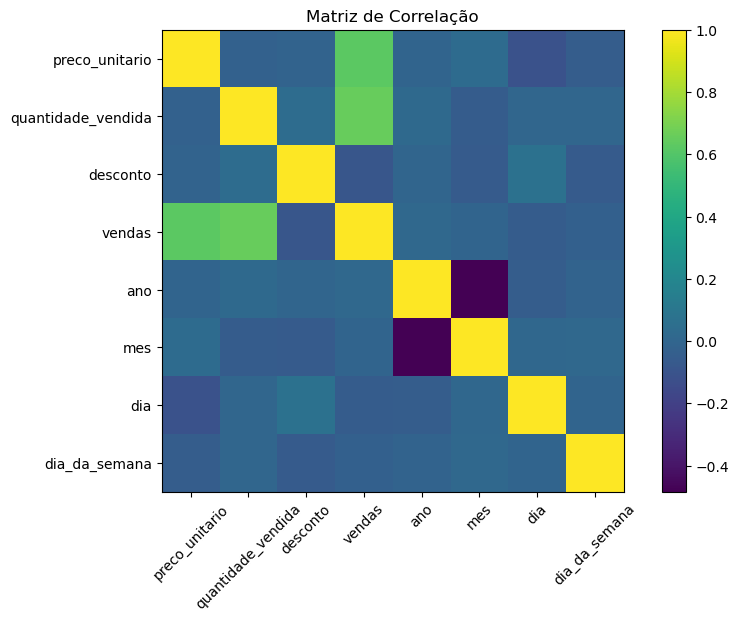

In [20]:
# Visualização da matriz de correlação

plt.figure(figsize=(10, 6))
plt.imshow(correlacao)
plt.colorbar()
plt.xticks(range(len(correlacao.columns)), correlacao.columns, rotation=45)
plt.yticks(range(len(correlacao.columns)), correlacao.columns)
plt.title("Matriz de Correlação")
plt.show()

### Interpretação da correlação

A matriz de correlação mostra que as variáveis `preco_unitario` e `quantidade_vendida` possuem as maiores correlações positivas com a variável alvo `vendas`.

Isso indica que essas variáveis são importantes para explicar o valor total vendido.

A variável `desconto` apresenta correlação negativa fraca com `vendas`, o que faz sentido, pois descontos maiores reduzem o valor final da venda.

As variáveis temporais, como `mes`, `dia` e `dia_da_semana`, apresentam baixa correlação com `vendas` neste dataset inicial.

In [21]:
# Visualizar as colunas disponíveis

df.columns

Index(['data', 'loja', 'categoria', 'preco_unitario', 'quantidade_vendida',
       'desconto', 'vendas', 'ano', 'mes', 'dia', 'dia_da_semana'],
      dtype='object')

In [22]:
# Definir variáveis explicativas e variável alvo

X = df[
    [
        "loja",
        "categoria",
        "preco_unitario",
        "quantidade_vendida",
        "desconto",
        "ano",
        "mes",
        "dia",
        "dia_da_semana"
    ]
]

y = df["vendas"]

# Visualizar as primeiras linhas das variáveis explicativas
X.head()

,loja,categoria,preco_unitario,quantidade_vendida,desconto,ano,mes,dia,dia_da_semana
0,Loja C,Roupas,119.69,6,0.21,2023,1,1,6
1,Loja A,Roupas,412.68,5,0.12,2023,1,2,0
2,Loja C,Alimentos,179.09,5,0.14,2023,1,3,1
3,Loja C,Roupas,180.33,47,0.21,2023,1,4,2
4,Loja A,Casa,25.58,23,0.01,2023,1,5,3


In [23]:
# Visualizar a variável alvo

y.head()

0     567.33
1    1815.79
2     770.09
3    6695.65
4     582.46
Name: vendas, dtype: float64

### Tratamento de variáveis categóricas

Os modelos de Machine Learning não trabalham diretamente com textos.

Por isso, as variáveis categóricas `loja` e `categoria` serão transformadas em variáveis numéricas usando One-Hot Encoding.

Esse processo cria novas colunas binárias indicando a presença ou ausência de cada categoria.

In [24]:
# Aplicar One-Hot Encoding nas variáveis categóricas

X_encoded = pd.get_dummies(X, columns=["loja", "categoria"], drop_first=True)

# Visualizar as primeiras linhas após transformação
X_encoded.head()

,preco_unitario,quantidade_vendida,desconto,ano,mes,dia,dia_da_semana,loja_Loja B,loja_Loja C,categoria_Casa,categoria_Eletrônicos,categoria_Roupas
0,119.69,6,0.21,2023,1,1,6,False,True,False,False,True
1,412.68,5,0.12,2023,1,2,0,False,False,False,False,True
2,179.09,5,0.14,2023,1,3,1,False,True,False,False,False
3,180.33,47,0.21,2023,1,4,2,False,True,False,False,True
4,25.58,23,0.01,2023,1,5,3,False,False,True,False,False


In [25]:
# Verificar as colunas finais do modelo

X_encoded.columns

Index(['preco_unitario', 'quantidade_vendida', 'desconto', 'ano', 'mes', 'dia',
       'dia_da_semana', 'loja_Loja B', 'loja_Loja C', 'categoria_Casa',
       'categoria_Eletrônicos', 'categoria_Roupas'],
      dtype='object')

### Separação entre treino e teste

Nesta etapa, os dados serão divididos em duas partes:

- **Treino:** usado para o modelo aprender os padrões dos dados
- **Teste:** usado para avaliar se o modelo consegue fazer boas previsões em dados novos

Será utilizada uma divisão de 80% para treino e 20% para teste.

In [26]:
# Importar função para separar treino e teste

from sklearn.model_selection import train_test_split

# Separar dados em treino e teste

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

# Verificar os tamanhos dos conjuntos
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (400, 12)
X_test: (100, 12)
y_train: (400,)
y_test: (100,)


## Modelo 1: Linear Regression

O primeiro modelo utilizado será a Regressão Linear.

Esse modelo tenta encontrar uma relação linear entre as variáveis explicativas e a variável alvo `vendas`.

Ele será usado como modelo base para comparação com modelos mais avançados.

In [27]:
# Importar o modelo de Regressão Linear

from sklearn.linear_model import LinearRegression

# Criar o modelo
modelo_lr = LinearRegression()

# Treinar o modelo
modelo_lr.fit(X_train, y_train)

print("Modelo Linear Regression treinado com sucesso.")

Modelo Linear Regression treinado com sucesso.


In [28]:
# Fazer previsões com o modelo Linear Regression

y_pred_lr = modelo_lr.predict(X_test)

# Visualizar as primeiras previsões
y_pred_lr[:10]

array([-1461.80252983,  4714.03957113,  6998.76908364,  5713.87550732,
        7128.49597345,  2271.24979033,  7720.63811358, 11266.42345099,
        8285.06941658,  8058.14951347])

In [29]:
# Comparar valores reais com valores previstos

comparacao_lr = pd.DataFrame({
    "Valor Real": y_test.values,
    "Valor Previsto": y_pred_lr
})

comparacao_lr.head(10)

,Valor Real,Valor Previsto
0,511.73,-1461.802530
1,2054.47,4714.039571
2,6521.86,6998.769084
3,4555.96,5713.875507
4,6698.59,7128.495973
5,348.44,2271.249790
6,4336.31,7720.638114
7,12341.34,11266.423451
8,8367.41,8285.069417
9,5175.57,8058.149513


### Avaliação do modelo Linear Regression

Para avaliar o desempenho do modelo, serão utilizadas três métricas:

- **MAE:** erro médio absoluto entre o valor real e o previsto
- **RMSE:** erro médio com maior penalização para erros grandes
- **R²:** indica o quanto o modelo explica da variação da variável alvo

Quanto menor o MAE e o RMSE, melhor.

Quanto mais próximo de 1 o R², melhor o desempenho do modelo.

In [30]:
# Importar métricas de avaliação

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calcular métricas da Linear Regression

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Avaliação do modelo Linear Regression")
print("MAE:", round(mae_lr, 2))
print("RMSE:", round(rmse_lr, 2))
print("R²:", round(r2_lr, 4))

Avaliação do modelo Linear Regression
MAE: 1451.34
RMSE: 1836.24
R²: 0.8326


### Interpretação do modelo Linear Regression

O modelo de Regressão Linear foi utilizado como primeiro modelo base.

Ele conseguiu identificar parte da relação entre as variáveis explicativas e a variável alvo `vendas`, principalmente porque `preco_unitario` e `quantidade_vendida` possuem relação direta com o valor vendido.

No entanto, como a Regressão Linear assume uma relação linear simples, ela pode apresentar limitações em problemas com interações entre variáveis, como preço, quantidade e desconto.

Além disso, o modelo pode gerar previsões negativas, o que não faz sentido no contexto de vendas.

## Modelo 2: Random Forest Regressor

O segundo modelo será o Random Forest Regressor.

Esse modelo utiliza várias árvores de decisão para fazer previsões e costuma capturar melhor relações não lineares entre as variáveis.

Ele será comparado com a Regressão Linear para verificar qual modelo apresenta melhor desempenho.

In [31]:
# Importar o modelo Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

# Criar o modelo
modelo_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Treinar o modelo
modelo_rf.fit(X_train, y_train)

print("Modelo Random Forest Regressor treinado com sucesso.")

Modelo Random Forest Regressor treinado com sucesso.


In [32]:
# Fazer previsões com o modelo Random Forest Regressor

y_pred_rf = modelo_rf.predict(X_test)

# Comparar valores reais com valores previstos

comparacao_rf = pd.DataFrame({
    "Valor Real": y_test.values,
    "Valor Previsto": y_pred_rf
})

comparacao_rf.head(10)

,Valor Real,Valor Previsto
0,511.73,552.7642
1,2054.47,1969.7611
2,6521.86,6603.2909
3,4555.96,4414.8334
4,6698.59,6954.2872
5,348.44,586.5514
6,4336.31,3441.6490
7,12341.34,12298.3381
8,8367.41,8581.9800
9,5175.57,5303.0598


### Avaliação do modelo Random Forest Regressor

O modelo Random Forest Regressor será avaliado com as mesmas métricas utilizadas na Regressão Linear:

- MAE
- RMSE
- R²

Isso permite comparar os dois modelos de forma justa.

In [33]:
# Calcular métricas do Random Forest Regressor

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Avaliação do modelo Random Forest Regressor")
print("MAE:", round(mae_rf, 2))
print("RMSE:", round(rmse_rf, 2))
print("R²:", round(r2_rf, 4))

Avaliação do modelo Random Forest Regressor
MAE: 343.14
RMSE: 494.39
R²: 0.9879


## Comparação dos modelos

Nesta etapa, os modelos treinados serão comparados usando as métricas MAE, RMSE e R².

O objetivo é identificar qual modelo apresentou melhor desempenho na previsão de vendas.

In [34]:
# Criar tabela comparativa dos modelos

resultados_modelos = pd.DataFrame({
    "Modelo": ["Linear Regression", "Random Forest Regressor"],
    "MAE": [mae_lr, mae_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "R²": [r2_lr, r2_rf]
})

# Arredondar os valores para melhor visualização
resultados_modelos["MAE"] = resultados_modelos["MAE"].round(2)
resultados_modelos["RMSE"] = resultados_modelos["RMSE"].round(2)
resultados_modelos["R²"] = resultados_modelos["R²"].round(4)

# Ordenar pelo melhor R²
resultados_modelos = resultados_modelos.sort_values(by="R²", ascending=False)

resultados_modelos

,Modelo,MAE,RMSE,R²
1,Random Forest Regressor,343.14,494.39,0.9879
0,Linear Regression,1451.34,1836.24,0.8326


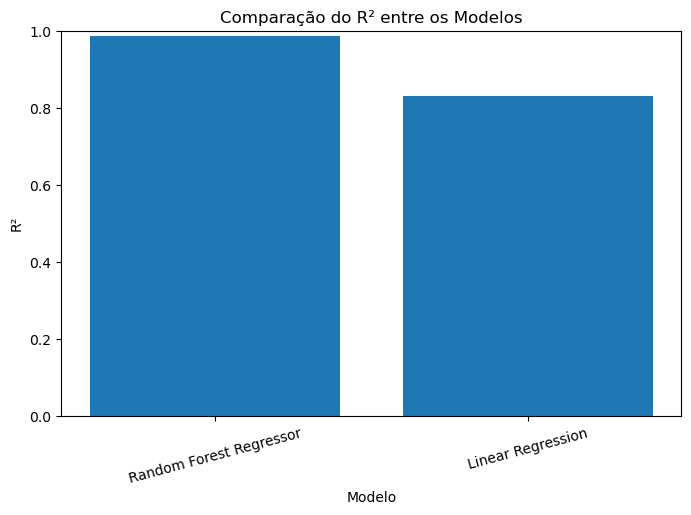

In [35]:
# Gráfico comparando o R² dos modelos

plt.figure(figsize=(8, 5))
plt.bar(resultados_modelos["Modelo"], resultados_modelos["R²"])
plt.title("Comparação do R² entre os Modelos")
plt.xlabel("Modelo")
plt.ylabel("R²")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

### Interpretação da comparação dos modelos

O modelo Random Forest Regressor apresentou o melhor desempenho geral.

Ele obteve menor MAE, menor RMSE e maior R² em comparação com a Regressão Linear.

Isso indica que o Random Forest conseguiu capturar melhor os padrões dos dados, principalmente porque o problema envolve relação entre preço, quantidade, desconto e vendas.

A Regressão Linear serviu como um bom modelo base, mas apresentou maior erro e menor capacidade de explicação da variável alvo.

## Importância das variáveis

Nesta etapa, será analisada a importância das variáveis utilizadas pelo modelo Random Forest Regressor.

Essa análise ajuda a entender quais variáveis mais contribuíram para a previsão das vendas.

In [36]:
# Importância das variáveis no modelo Random Forest

importancias = modelo_rf.feature_importances_

feature_importance = pd.DataFrame({
    "Variável": X_encoded.columns,
    "Importância": importancias
})

feature_importance = feature_importance.sort_values(by="Importância", ascending=False)

feature_importance

,Variável,Importância
1,quantidade_vendida,0.493012
0,preco_unitario,0.479396
2,desconto,0.016611
4,mes,0.003081
5,dia,0.003000
6,dia_da_semana,0.001983
8,loja_Loja C,0.000625
7,loja_Loja B,0.000620
11,categoria_Roupas,0.000517
9,categoria_Casa,0.000485


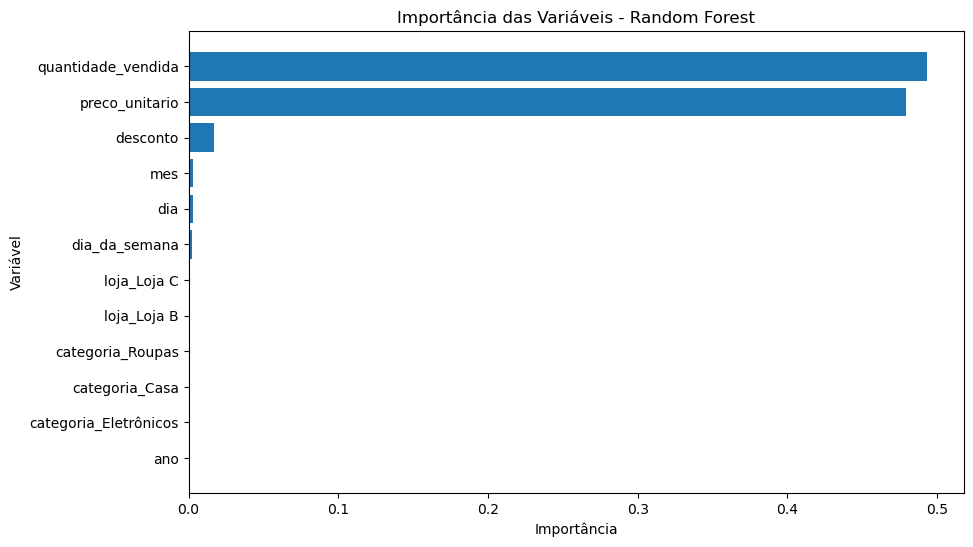

In [37]:
# Gráfico de importância das variáveis

plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Variável"], feature_importance["Importância"])
plt.title("Importância das Variáveis - Random Forest")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.gca().invert_yaxis()
plt.show()

### Interpretação da importância das variáveis

O modelo Random Forest Regressor identificou que as variáveis mais importantes para prever `vendas` foram:

- `quantidade_vendida`
- `preco_unitario`
- `desconto`

Esse resultado faz sentido no contexto do problema, pois o valor final de vendas depende diretamente da quantidade vendida, do preço unitário e do desconto aplicado.

As variáveis de loja, categoria e tempo apresentaram baixa importância neste dataset inicial.

## Comparação entre valores reais e previstos

Nesta etapa, será criado um gráfico para comparar os valores reais de vendas com os valores previstos pelo melhor modelo.

O objetivo é verificar visualmente se as previsões estão próximas dos valores reais.

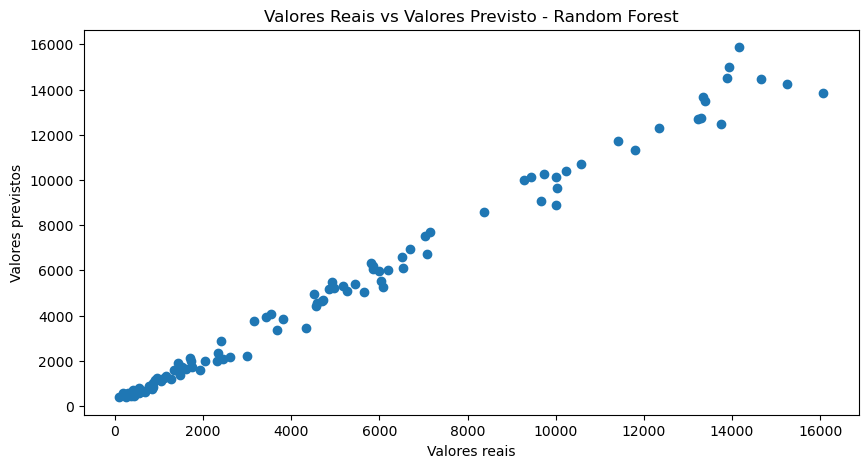

In [38]:
# Gráfico de valores reais vs previstos - Random Forest

plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_rf)
plt.title("Valores Reais vs Valores Previsto - Random Forest")
plt.xlabel("Valores reais")
plt.ylabel("Valores previstos")
plt.show()

### Interpretação dos valores reais vs previstos

O gráfico mostra uma boa aproximação entre os valores reais e os valores previstos pelo modelo Random Forest Regressor.

Os pontos seguem uma tendência crescente bem definida, indicando que o modelo conseguiu capturar o comportamento geral das vendas.

Como o R² também foi elevado, essa análise visual reforça que o Random Forest apresentou bom desempenho neste dataset.

## Salvamento do melhor modelo

Após a comparação dos modelos, o Random Forest Regressor foi escolhido como melhor modelo.

Nesta etapa, o modelo será salvo em arquivo para permitir reutilização futura sem necessidade de novo treinamento.

In [39]:
# Salvar o melhor modelo treinado

import joblib

modelo_path = os.path.join(MODELS_PATH, "random_forest_sales_model.pkl")

joblib.dump(modelo_rf, modelo_path)

print("Modelo salvo com sucesso em:")
print(modelo_path)

Modelo salvo com sucesso em:
C:\Users\andre\sales-forecasting-ml\models\random_forest_sales_model.pkl


## Conclusão final

Neste projeto foi desenvolvido um fluxo completo de Machine Learning para previsão de vendas utilizando modelos de regressão.

O projeto passou pelas seguintes etapas:

- definição do problema de negócio
- criação e carregamento do dataset
- análise inicial dos dados
- análise exploratória com gráficos
- criação de variáveis temporais
- tratamento de variáveis categóricas com One-Hot Encoding
- separação entre treino e teste
- treinamento de modelos de regressão
- avaliação com MAE, RMSE e R²
- comparação entre modelos
- análise da importância das variáveis
- salvamento do melhor modelo

Foram treinados dois modelos:

- Linear Regression
- Random Forest Regressor

O modelo com melhor desempenho foi o **Random Forest Regressor**, apresentando menor erro e maior capacidade de explicação da variável alvo `vendas`.

As variáveis mais importantes para a previsão foram:

- `quantidade_vendida`
- `preco_unitario`
- `desconto`

Esses resultados fazem sentido para o contexto de negócio, pois o valor de vendas depende diretamente da quantidade vendida, do preço unitário e do desconto aplicado.

Este projeto reforça conhecimentos importantes de Ciência de Dados aplicada, especialmente em problemas de regressão, avaliação de modelos e interpretação de resultados para tomada de decisão.